Clinical Trial Radar - Stage 1

Definirea problemei si analiza datelor de intrare

Acest notebook este pentru prima etapa a proiectului. Scopul lui este sa explice problema, sa prezinte datele folosite si sa faca o analiza initiala a datasetului obtinut din ClinicalTrials.gov.

Notebook-ul poate fi rulat din radacina proiectului sau din folderul docs. Codul cauta automat folderul data/raw.


1. Problema abordata

Studiile clinice pot fi greu de planificat deoarece informatiile despre studii similare sunt imprastiate in registre publice si trebuie comparate manual. Pentru o echipa care vrea sa porneasca un nou studiu, este important sa stie unde exista deja multe studii active, unde s-au finalizat studii in trecut si cat dureaza in mod obisnuit un studiu.

Proiectul Clinical Trial Radar propune un sistem inteligent care analizeaza automat studiile clinice pentru o anumita boala si o anumita faza. Sistemul foloseste date publice din ClinicalTrials.gov si genereaza indicatori utili pentru analiza de fezabilitate.

Intrebarea principala a proiectului este:

Pentru o anumita boala si o anumita faza, cat de aglomerat este peisajul studiilor clinice si ce tari par mai potrivite pentru recrutare?


2. Inputuri si outputuri

Inputuri:
- boala analizata, de exemplu diabetes, breast cancer sau covid-19;
- faza studiului, de exemplu Phase 1, Phase 2 sau Phase 3;
- numarul maxim de studii care vor fi descarcate;
- optional, tara sau regiunea de interes.

Outputuri:
- tabel cu studii relevante;
- distributie pe statusuri, tari si ani;
- grafic de trend;
- harta pe tari;
- metrica de aglomerare pentru studiile active/recruiting;
- estimare pentru durata studiilor;
- feasibility snapshot in format HTML sau PPTX.


3. Sursa datelor

Datele folosite provin din ClinicalTrials.gov, un registru public de studii clinice. Aplicatia descarca datele cu ajutorul unui modul de ingestie si le salveaza in folderul data/raw sub forma de fisiere CSV.

In aceasta etapa analizam fisierele CSV deja descarcate in proiect.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

def find_project_root():
    current = Path.cwd().resolve()
    for path in [current] + list(current.parents):
        if (path / "data" / "raw").exists():
            return path
    return current

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Data folder exists:", DATA_DIR.exists())

Project root: D:\proiectAI_2026
Data folder: D:\proiectAI_2026\data\raw
Data folder exists: True


4. Incarcarea datelor

Incarcam toate fisierele CSV din data/raw. Fiecare fisier primeste o coloana suplimentara SourceFile, ca sa stim din ce fisier provine fiecare rand.


In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

print("Numar fisiere CSV gasite:", len(csv_files))
for file in csv_files:
    print("-", file.name)

dataframes = []

for file in csv_files:
    try:
        temp = pd.read_csv(file)
        temp["SourceFile"] = file.name
        dataframes.append(temp)
    except Exception as error:
        print("Nu am putut citi fisierul:", file.name)
        print(error)

if dataframes:
    df = pd.concat(dataframes, ignore_index=True)
else:
    df = pd.DataFrame()

print("Numar total de randuri:", len(df))
print("Numar total de coloane:", len(df.columns))
df.head()

Numar fisiere CSV gasite: 9
- diabetes_Phase_1_20260517T155730Z.csv
- diabetes_Phase_2_20260517T154939Z.csv
- diabetes_Phase_2_20260517T154942Z.csv
- diabetes_Phase_2_20260517T155006Z.csv
- diabetes_Phase_2_20260517T155413Z.csv
- diabetes_Phase_2_20260517T155834Z.csv
- diabetes_Phase_2_20260517T155835Z.csv
- diabetes_Phase_2_20260517T160031Z.csv
- diabetes_Phase_2_20260517T160041Z.csv
Numar total de randuri: 1800
Numar total de coloane: 30


,NCTId,OrgStudyId,BriefTitle,OfficialTitle,OverallStatus,LastKnownStatus,StartDate,PrimaryCompletionDate,CompletionDate,StudyType,Phase,EnrollmentCount,Condition,Keywords,BriefSummary,DetailedDescription,EligibilityCriteria,HealthyVolunteers,Sex,MinimumAge,StdAges,Locations,LocationCountry,LocationCity,LocationFacility,PrimaryOutcomes,LeadSponsor,LeadSponsorClass,VersionHolder,SourceFile
0,NCT03939143,DDS18-033BE,A Study to Investigate the Bioequivalence Test of DA-1229_01(A) at Fasting State,"Randomized, Open Label, Single Oral Administration at Fasting State, 2 x 2 Crossover Study to Investigate the Bioequ...",COMPLETED,NaN,2019-02-07,2019-04-04,2019-04-04,INTERVENTIONAL,PHASE1,34.0,Type2 Diabetes,NaN,A study demonstrates the bioequivalence of DA-1229\_01(A) at Fasting State when compared with Sugamet sustained-rele...,NaN,Inclusion Criteria:\r\n\r\n* Adult patients over 19 years of age at the time of health examination\r\n* Female patie...,True,ALL,19 Years,ADULT; OLDER_ADULT,"Metro Hospital, Anyang-si, Gyeonggi-do, South Korea",South Korea,Anyang-si,Metro Hospital,Area under the concentration-time curve(AUCt) | Hour -1 ~ Hour 72; Maximum plasmaconcentration of drug in plasma(Cma...,"Dong-A ST Co., Ltd.",INDUSTRY,2026-05-15,diabetes_Phase_1_20260517T155730Z.csv
1,NCT02603510,PDY13502,Assessment of the Safety of SAR342434 and Humalog® When Administered as Continuous Subcutaneous Insulin Infusion,"A Randomized, 2X4 Week, Active-Controlled, Open-Label, 2-Treatment Arm, 2-Period Cross-Over Study Assessing the Safe...",COMPLETED,NaN,2015-11,2016-04,2016-04,INTERVENTIONAL,PHASE1,27.0,Type 1 Diabetes Mellitus,NaN,Primary Objective:\r\n\r\n* Assess the safety of SAR342434 and Humalog when used in external pumps.\r\n\r\nSecondary...,The study duration for each patient will be approximately 10 weeks.,Inclusion criteria :\r\n\r\n* Male and female subjects above the age of 18.\r\n* Patients with type 1 diabetes melli...,False,ALL,19 Years,ADULT; OLDER_ADULT,"Investigational Site Number 840002, Little Rock, Arkansas, United States; Investigational Site Number 840001, Denver...",United States; United States,Little Rock; Denver,Investigational Site Number 840002; Investigational Site Number 840001,Frequency of infusion set occlusions | 4 weeks,Sanofi,INDUSTRY,2026-05-15,diabetes_Phase_1_20260517T155730Z.csv
2,NCT05553938,2000033412,Effects of Acute and Chronic Empagliflozin Heart Failure,Renal Mechanistic Effects of Acute and Chronic Empagliflozin in Heart Failure,RECRUITING,NaN,2023-08-04,2025-11,2025-11,INTERVENTIONAL,PHASE1,60.0,Heart Failure,NaN,"This is a 60-patient randomized, double-blind, placebo-controlled mechanistic study to understand the utility of emp...","This is a 60-patient randomized, double-blind, placebo-controlled mechanistic study to understand the utility of emp...",Inclusion Criteria:\r\n\r\n* A clinical diagnosis of worsening heart failure (worsening of congestive symptoms with ...,False,ALL,18 Years,ADULT; OLDER_ADULT,"Yale New Haven Hospital, New Haven, Connecticut, United States; Yale University, New Haven, Connecticut, United States",United States; United States,New Haven; New Haven,Yale New Haven Hospital; Yale University,Natriuretic effect of empagliflozin or placebo as an adjuvant to loop diuretic therapy | Day 1; Change in plasma vol...,Yale University,OTHER,2026-05-15,diabetes_Phase_1_20260517T155730Z.csv
3,NCT01881958,0224-13-HMO-CTIL,The Safety and Efficacy of Administrating DiaPep277® Vaccination in Type 1 Diabetes Patients.,NaN,WITHDRAWN,NaN,2015-01,2016-01,2017-01,INTERVENTIONAL,PHASE1; PHASE2,0.0,Type One Diabetes,NaN,Type 1 diabetes is caused by an autoimmune process resulting in a selective destruction of the pancreatic insulin-se...,NaN,Inclusion Criteria:\r\n\r\n1. Fasting C-peptide levels \>= 0.2nmol/L.\r\n2. Diagnosis of type 1 diabetes\r\n3. No pr...,False,ALL,20 Years,ADULT,NaN,NaN,NaN,NaN,efficacy will be measured by comparing Hemoglobin A1c | two years,Hadassah Medical Organization,OTHER,2

5. Coloane importante

Pentru analiza de fezabilitate ne intereseaza in special urmatoarele campuri:

- NCTId: identificatorul studiului clinic;
- BriefTitle: titlul scurt al studiului;
- OverallStatus: statusul studiului, de exemplu Recruiting sau Completed;
- Phase: faza studiului clinic;
- StartDate: data de inceput;
- CompletionDate: data de finalizare;
- LocationCountry: tara sau tarile in care are loc studiul;
- LocationCity: orasul sau orasele in care are loc studiul;
- EnrollmentCount: numarul de participanti;
- EligibilityCriteria: criterii de includere si excludere;
- PrimaryOutcomes: obiectivele principale ale studiului.


In [3]:
print("Coloanele disponibile:")
for col in df.columns:
    print("-", col)

Coloanele disponibile:
- NCTId
- OrgStudyId
- BriefTitle
- OfficialTitle
- OverallStatus
- LastKnownStatus
- StartDate
- PrimaryCompletionDate
- CompletionDate
- StudyType
- Phase
- EnrollmentCount
- Condition
- Keywords
- BriefSummary
- DetailedDescription
- EligibilityCriteria
- HealthyVolunteers
- Sex
- MinimumAge
- StdAges
- Locations
- LocationCountry
- LocationCity
- LocationFacility
- PrimaryOutcomes
- LeadSponsor
- LeadSponsorClass
- VersionHolder
- SourceFile


6. Dimensiunea datasetului

Verificam cate studii avem in total si cate studii unice exista pe baza identificatorului NCTId.


In [4]:
if not df.empty:
    total_rows = len(df)
    unique_trials = df["NCTId"].nunique() if "NCTId" in df.columns else "coloana lipsa"
    print("Randuri totale:", total_rows)
    print("Studii unice:", unique_trials)
else:
    print("Nu exista date incarcate.")

Randuri totale: 1800
Studii unice: 371


7. Valori lipsa

Datele din registre publice pot avea campuri lipsa. De exemplu, unele studii nu au data completa de finalizare, locatie completa sau criterii de eligibilitate detaliate.

Mai jos calculam cate valori lipsa exista pentru coloanele importante.


In [5]:
important_columns = [
    "NCTId",
    "BriefTitle",
    "OverallStatus",
    "Phase",
    "StartDate",
    "CompletionDate",
    "LocationCountry",
    "LocationCity",
    "EnrollmentCount",
    "EligibilityCriteria",
    "PrimaryOutcomes",
]

existing_columns = [col for col in important_columns if col in df.columns]

if existing_columns:
    missing_summary = (
        df[existing_columns]
        .isna()
        .sum()
        .reset_index()
    )
    missing_summary.columns = ["Column", "MissingValues"]
    missing_summary["MissingPercent"] = (missing_summary["MissingValues"] / len(df) * 100).round(2)
    display(missing_summary)
else:
    print("Nu s-au gasit coloanele importante in dataset.")

,Column,MissingValues,MissingPercent
0,NCTId,0,0.00
1,BriefTitle,0,0.00
2,OverallStatus,0,0.00
3,Phase,0,0.00
4,StartDate,10,0.56
5,CompletionDate,46,2.56
6,LocationCountry,118,6.56
7,LocationCity,118,6.56
8,EnrollmentCount,10,0.56
9,EligibilityCriteria,0,0.00


8. Distributia studiilor dupa status

Statusul studiului este important pentru ca arata daca studiile sunt active, in recrutare, finalizate sau retrase. Pentru metrica de aglomerare ne intereseaza in special studiile active sau in recrutare.


,NumberOfStudies
OverallStatus,
COMPLETED,1086
TERMINATED,258
WITHDRAWN,110
UNKNOWN,103
RECRUITING,86
ACTIVE_NOT_RECRUITING,85
NOT_YET_RECRUITING,70
SUSPENDED,1
ENROLLING_BY_INVITATION,1


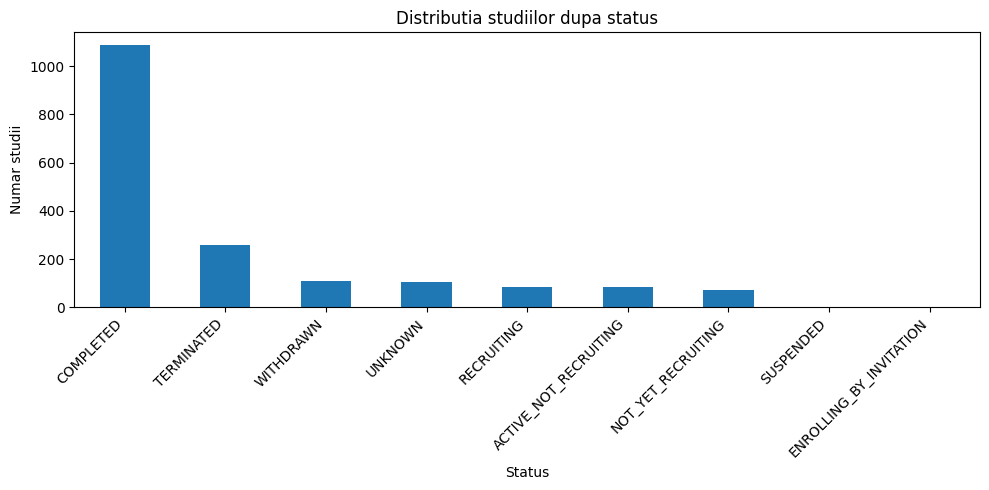

In [6]:
if "OverallStatus" in df.columns and not df.empty:
    status_counts = df["OverallStatus"].fillna("UNKNOWN").value_counts()
    display(status_counts.to_frame("NumberOfStudies"))

    plt.figure(figsize=(10, 5))
    status_counts.plot(kind="bar")
    plt.title("Distributia studiilor dupa status")
    plt.xlabel("Status")
    plt.ylabel("Numar studii")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Coloana OverallStatus lipseste.")

9. Distributia studiilor pe faze

Verificam fazele studiilor existente in date. Uneori un studiu poate avea mai multe faze mentionate, de exemplu PHASE2; PHASE3.


,NumberOfStudies
Phase,
PHASE2,1176
PHASE1; PHASE2,273
PHASE2; PHASE3,192
PHASE1,140
EARLY_PHASE1,19


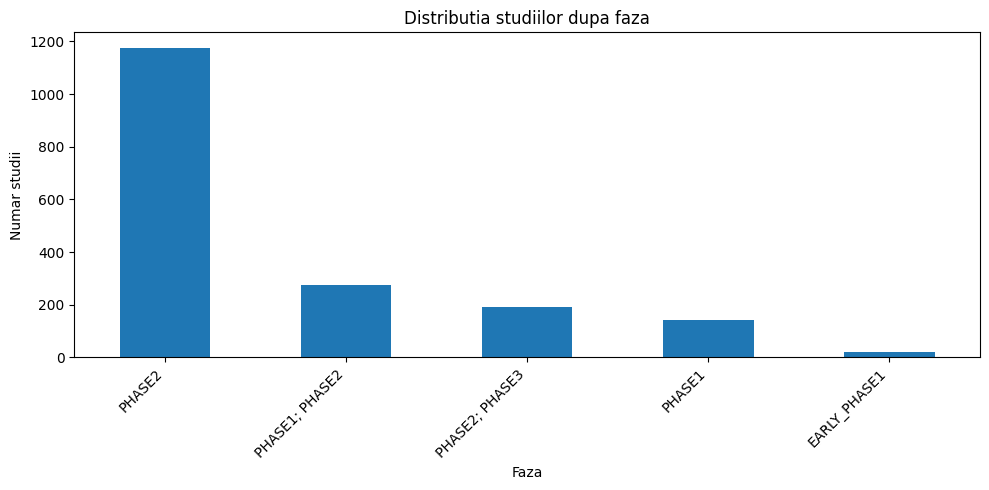

In [7]:
if "Phase" in df.columns and not df.empty:
    phase_counts = df["Phase"].fillna("UNKNOWN").value_counts()
    display(phase_counts.to_frame("NumberOfStudies"))

    plt.figure(figsize=(10, 5))
    phase_counts.plot(kind="bar")
    plt.title("Distributia studiilor dupa faza")
    plt.xlabel("Faza")
    plt.ylabel("Numar studii")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Coloana Phase lipseste.")

10. Distributia geografica

Pentru analiza de fezabilitate este important sa vedem in ce tari exista cele mai multe studii. Daca o tara are multe studii active, poate exista competitie mai mare pentru recrutarea pacientilor.

Unele randuri contin mai multe tari separate prin punct si virgula. De aceea transformam aceste valori in liste si le explodam.


,NumberOfTrialLocations
Country,
United States,15073
Canada,789
United Kingdom,733
Poland,681
Australia,597
Japan,589
Germany,548
France,481
Spain,405


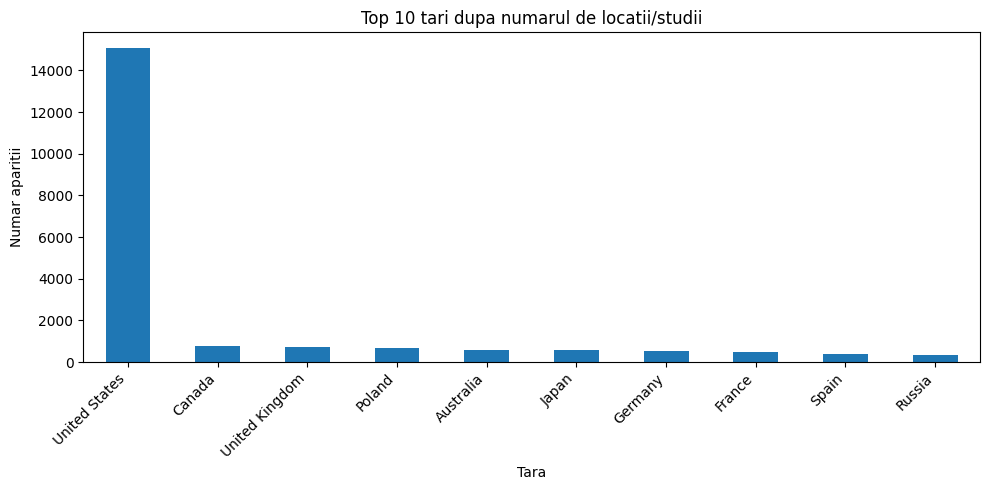

In [8]:
def split_semicolon_values(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(";") if item.strip()]

if "LocationCountry" in df.columns and not df.empty:
    countries = df[["NCTId", "OverallStatus", "LocationCountry"]].copy()
    countries["Country"] = countries["LocationCountry"].apply(split_semicolon_values)
    countries = countries.explode("Country")
    countries = countries[countries["Country"].notna() & (countries["Country"] != "")]

    country_counts = countries["Country"].value_counts().head(10)
    display(country_counts.to_frame("NumberOfTrialLocations"))

    plt.figure(figsize=(10, 5))
    country_counts.plot(kind="bar")
    plt.title("Top 10 tari dupa numarul de locatii/studii")
    plt.xlabel("Tara")
    plt.ylabel("Numar aparitii")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Coloana LocationCountry lipseste.")

11. Trend in timp

Pentru trend folosim StartDate si extragem anul de inceput. Acest grafic arata cum a evoluat numarul de studii in timp.


,NumberOfStudies
StartYear,
2000,8
2002,1
2004,8
2006,33
2008,9
2009,24
2010,19
2011,1
2013,9


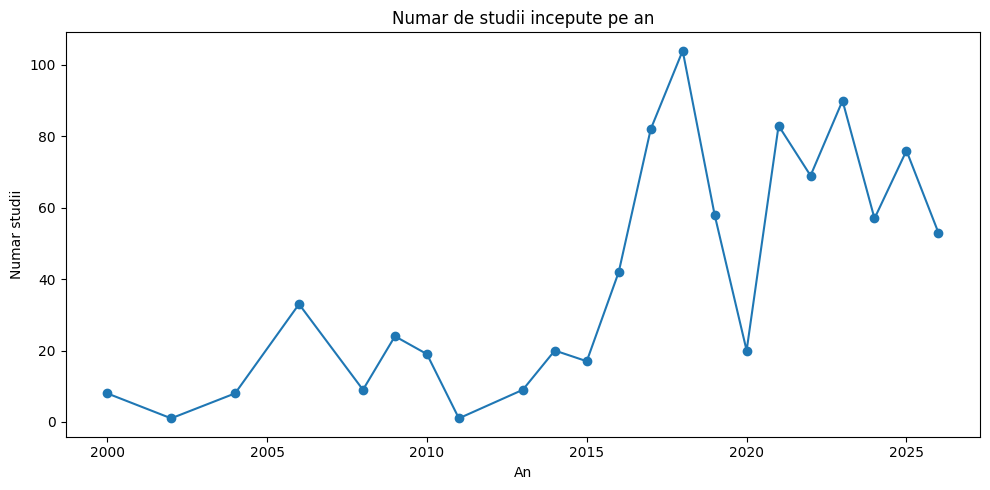

In [9]:
if "StartDate" in df.columns and not df.empty:
    trend_df = df.copy()
    trend_df["ParsedStartDate"] = pd.to_datetime(trend_df["StartDate"], errors="coerce")
    trend_df["StartYear"] = trend_df["ParsedStartDate"].dt.year

    yearly_counts = trend_df["StartYear"].dropna().astype(int).value_counts().sort_index()
    display(yearly_counts.to_frame("NumberOfStudies"))

    plt.figure(figsize=(10, 5))
    yearly_counts.plot(kind="line", marker="o")
    plt.title("Numar de studii incepute pe an")
    plt.xlabel("An")
    plt.ylabel("Numar studii")
    plt.tight_layout()
    plt.show()
else:
    print("Coloana StartDate lipseste.")

12. Trend pe statusuri importante

Pentru cerinta proiectului este util sa comparam studiile Recruiting cu cele Completed. Daca datele contin aceste statusuri, generam un tabel si un grafic pentru evolutia lor in timp.


OverallStatusClean,COMPLETED,RECRUITING
StartYear,,
2000.0,8,0
2002.0,1,0
2004.0,8,0
2006.0,25,0
2008.0,9,0
2009.0,16,0
2010.0,10,0
2011.0,1,0
2013.0,9,0


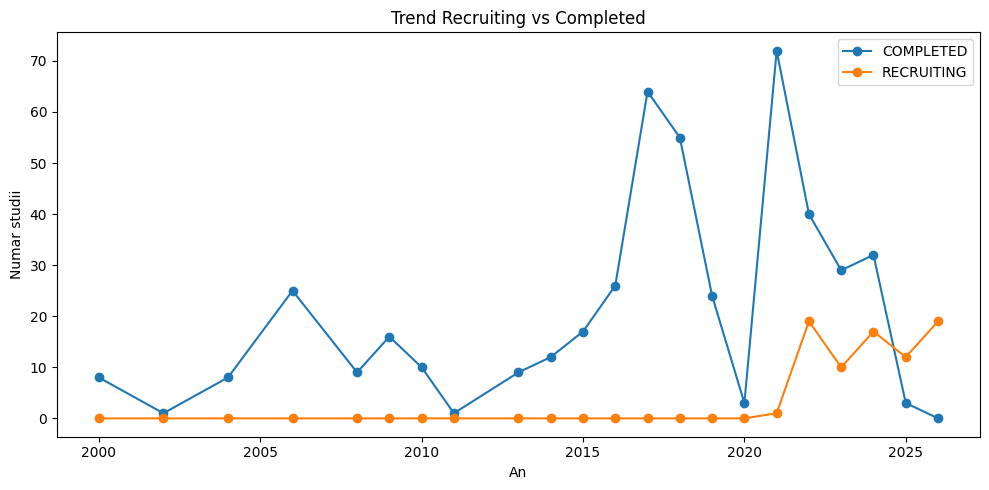

In [10]:
if {"StartDate", "OverallStatus"}.issubset(df.columns) and not df.empty:
    trend_status = df.copy()
    trend_status["ParsedStartDate"] = pd.to_datetime(trend_status["StartDate"], errors="coerce")
    trend_status["StartYear"] = trend_status["ParsedStartDate"].dt.year
    trend_status["OverallStatusClean"] = trend_status["OverallStatus"].fillna("UNKNOWN").str.upper()

    selected_statuses = ["RECRUITING", "COMPLETED"]
    filtered = trend_status[trend_status["OverallStatusClean"].isin(selected_statuses)]

    if not filtered.empty:
        pivot = (
            filtered
            .pivot_table(
                index="StartYear",
                columns="OverallStatusClean",
                values="NCTId",
                aggfunc="count",
                fill_value=0
            )
            .sort_index()
        )

        display(pivot)

        plt.figure(figsize=(10, 5))
        for column in pivot.columns:
            plt.plot(pivot.index, pivot[column], marker="o", label=column)
        plt.title("Trend Recruiting vs Completed")
        plt.xlabel("An")
        plt.ylabel("Numar studii")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Nu exista statusuri Recruiting sau Completed in datele incarcate.")
else:
    print("Coloanele necesare lipsesc.")

13. Aglomerare pentru recrutare

O varianta simpla pentru crowdedness este numarul de studii active sau in recrutare din fiecare tara. Cu cat o tara are mai multe studii active, cu atat poate exista competitie mai mare pentru recrutarea participantilor.


,ActiveOrRecruitingStudies
Country,
United States,1148
Poland,153
United Kingdom,56
Spain,48
Argentina,40
Denmark,32
Chile,24
Australia,24
Israel,24


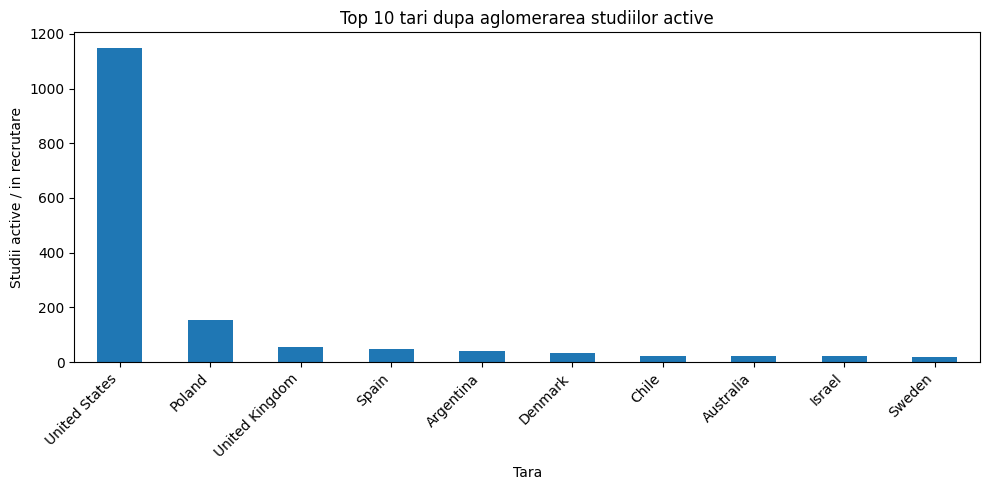

In [11]:
active_statuses = {
    "RECRUITING",
    "ACTIVE_NOT_RECRUITING",
    "NOT_YET_RECRUITING",
    "ENROLLING_BY_INVITATION"
}

if {"OverallStatus", "LocationCountry"}.issubset(df.columns) and not df.empty:
    active_df = df.copy()
    active_df["OverallStatusClean"] = active_df["OverallStatus"].fillna("UNKNOWN").str.upper()
    active_df = active_df[active_df["OverallStatusClean"].isin(active_statuses)]

    active_countries = active_df[["NCTId", "OverallStatus", "LocationCountry"]].copy()
    active_countries["Country"] = active_countries["LocationCountry"].apply(split_semicolon_values)
    active_countries = active_countries.explode("Country")
    active_countries = active_countries[active_countries["Country"].notna() & (active_countries["Country"] != "")]

    crowdedness = active_countries["Country"].value_counts().head(10)
    display(crowdedness.to_frame("ActiveOrRecruitingStudies"))

    plt.figure(figsize=(10, 5))
    crowdedness.plot(kind="bar")
    plt.title("Top 10 tari dupa aglomerarea studiilor active")
    plt.xlabel("Tara")
    plt.ylabel("Studii active / in recrutare")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Coloanele necesare lipsesc.")

14. Durata studiilor

Pentru estimarea duratei folosim diferenta dintre StartDate si CompletionDate. Rezultatul este aproximativ deoarece unele date pot fi incomplete sau lipsa.


,DurationDays
count,836.000000
mean,998.455742
std,984.513526
min,0.000000
25%,412.000000
50%,729.500000
75%,1286.000000
max,7096.000000


Durata mediana in zile: 729.5
Durata mediana in luni: 23.97


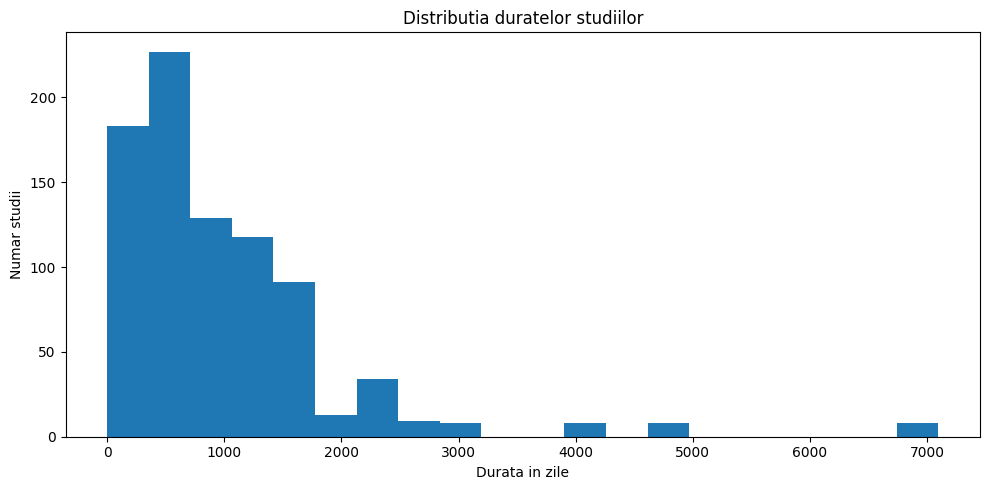

In [12]:
if {"StartDate", "CompletionDate"}.issubset(df.columns) and not df.empty:
    duration_df = df.copy()
    duration_df["ParsedStartDate"] = pd.to_datetime(duration_df["StartDate"], errors="coerce")
    duration_df["ParsedCompletionDate"] = pd.to_datetime(duration_df["CompletionDate"], errors="coerce")
    duration_df["DurationDays"] = (duration_df["ParsedCompletionDate"] - duration_df["ParsedStartDate"]).dt.days
    duration_df = duration_df[duration_df["DurationDays"].notna() & (duration_df["DurationDays"] >= 0)]

    if not duration_df.empty:
        duration_summary = duration_df["DurationDays"].describe().to_frame("DurationDays")
        display(duration_summary)

        print("Durata mediana in zile:", round(duration_df["DurationDays"].median(), 2))
        print("Durata mediana in luni:", round(duration_df["DurationDays"].median() / 30.44, 2))

        plt.figure(figsize=(10, 5))
        duration_df["DurationDays"].plot(kind="hist", bins=20)
        plt.title("Distributia duratelor studiilor")
        plt.xlabel("Durata in zile")
        plt.ylabel("Numar studii")
        plt.tight_layout()
        plt.show()
    else:
        print("Nu exista suficiente date valide pentru calculul duratei.")
else:
    print("Coloanele StartDate si CompletionDate lipsesc.")

15. Observatii initiale

Completati aceasta sectiune dupa ce rulati notebook-ul.

Exemplu de observatii care pot fi scrise:
- datasetul contine mai multe studii pentru diabetes, in special pentru Phase 2;
- cele mai frecvente statusuri sunt Completed si Recruiting;
- Statele Unite apar frecvent ca locatie pentru studii;
- unele coloane au valori lipsa, mai ales pentru locatie sau descrieri detaliate;
- datele sunt potrivite pentru metrici de tip trend, crowdedness si cycle time.
